### Importación de Librerías y Configuración del Entorno

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from sklearn.metrics import (
    precision_recall_curve,
    roc_curve,
    auc,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    f1_score
)
import joblib

# Permitir importar desde src/
BASE_DIR = Path("..")
sys.path.append(str(BASE_DIR))

from src.model import Autoencoder

# Configuración gráfica
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"⚡ Dispositivo para inferencia: {device}")

⚡ Dispositivo para inferencia: cpu


### Carga de Datos de Prueba y Modelo Entrenado

In [2]:
PROCESSED_DATA_PATH = BASE_DIR / "data" / "processed"
MODELS_DIR = BASE_DIR / "models"

# 1. Cargar datos procesados y sus etiquetas reales (0: Lícita, 1: Ilícita)
X_test = np.load(PROCESSED_DATA_PATH / "X_test.npy")
y_test = np.load(PROCESSED_DATA_PATH / "y_test.npy")

# Cargar set de validación (exclusivo para selección de umbral)
X_val = np.load(PROCESSED_DATA_PATH / "X_val.npy")
y_val = np.load(PROCESSED_DATA_PATH / "y_val.npy")

# Cargar el scaler entrenado para interpretar los errores en el espacio original
scaler = joblib.load(PROCESSED_DATA_PATH / "scaler.joblib")

print(f"Dimensiones de X_test: {X_test.shape}")
print(f"Distribución de etiquetas y_test -> Lícitas (0): {(y_test == 0).sum()} | Ilícitas (1): {(y_test == 1).sum()}")

# 2. Cargar la arquitectura e hiperparámetros del modelo
INPUT_DIM = X_test.shape[1] # 165
BOTTLENECK_DIM = 16

model = Autoencoder(input_dim=INPUT_DIM, bottleneck_dim=BOTTLENECK_DIM)
model.load_state_dict(torch.load(MODELS_DIR / "autoencoder_licit.pth", map_location=device))
model.to(device)
model.eval()

print("✅ Modelo entrenado cargado exitosamente en modo evaluación (eval).")

Dimensiones de X_test: (13123, 165)
Distribución de etiquetas y_test -> Lícitas (0): 12295 | Ilícitas (1): 828
✅ Modelo entrenado cargado exitosamente en modo evaluación (eval).


### Cálculo del Error de Reconstrucción ($\mathcal{L}_{\text{MSE}}$) Muestra por Muestra
Calculamos la pérdida de reconstrucción por transacción:$$E_i = \frac{1}{d} \sum_{j=1}^{d} (x_{ij} - \hat{x}_{ij})^2$$

In [3]:
# Convertir conjuntos a Tensor de PyTorch
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32).to(device)

# Realizar inferencia sin calcular gradientes para ambos conjuntos
with torch.no_grad():
    X_test_reconstructed = model(X_test_tensor)
    X_val_reconstructed = model(X_val_tensor)

# Convertir a numpy
X_test_reconstructed = X_test_reconstructed.cpu().numpy()
X_val_reconstructed = X_val_reconstructed.cpu().numpy()

# Transformar a la escala original para comparar errores en el espacio de características real
X_test_original = scaler.inverse_transform(X_test)
X_val_original = scaler.inverse_transform(X_val)
X_test_reconstructed_original = scaler.inverse_transform(X_test_reconstructed)
X_val_reconstructed_original = scaler.inverse_transform(X_val_reconstructed)

# Error Cuadrático Medio por muestra (promedio a lo largo de las características) en espacio original
reconstruction_errors_test = np.mean(np.square(X_test_original - X_test_reconstructed_original), axis=1)
reconstruction_errors_val = np.mean(np.square(X_val_original - X_val_reconstructed_original), axis=1)


print(f"Error de Reconstrucción Promedio Test: {reconstruction_errors_test.mean():.4f}")
print(f"  └─ Promedio en Lícitas (Clase 0) Test: {reconstruction_errors_test[y_test == 0].mean():.4f}")
print(f"  └─ Promedio en Ilícitas (Clase 1) Test: {reconstruction_errors_test[y_test == 1].mean():.4f}")
print(f"Error de Reconstrucción Promedio Val:  {reconstruction_errors_val.mean():.4f}")
print(f"  └─ Promedio en Lícitas (Clase 0) Val:  {reconstruction_errors_val[y_val == 0].mean():.4f}")
print(f"  └─ Promedio en Ilícitas (Clase 1) Val:  {reconstruction_errors_val[y_val == 1].mean():.4f}")

Error de Reconstrucción Promedio Test: 2.0503


  └─ Promedio en Lícitas (Clase 0) Test: 2.1304
  └─ Promedio en Ilícitas (Clase 1) Test: 0.8611
Error de Reconstrucción Promedio Val:  5.7020
  └─ Promedio en Lícitas (Clase 0) Val:  6.3827
  └─ Promedio en Ilícitas (Clase 1) Val:  0.5515


### Visualización de Distribuciones del Error (Hipótesis de la Variedad)

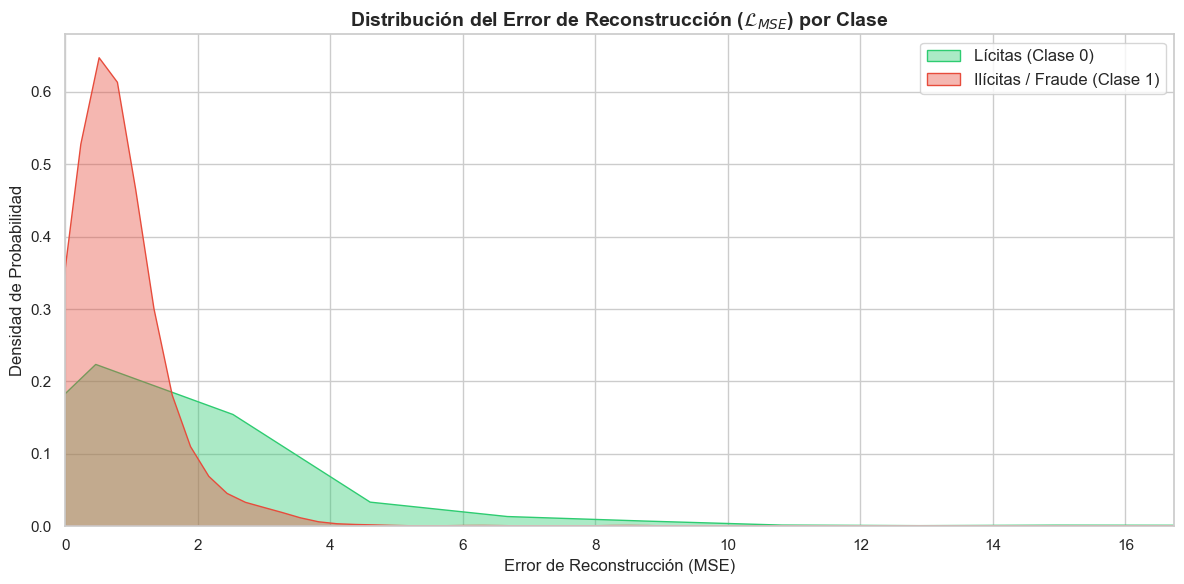

In [4]:
fig, ax = plt.subplots(figsize=(12, 6))

# Histogramas/KDE por clase (usando errores de TEST)
sns.kdeplot(reconstruction_errors_test[y_test == 0], label="Lícitas (Clase 0)", color="#2ecc71", fill=True, alpha=0.4, ax=ax)
sns.kdeplot(reconstruction_errors_test[y_test == 1], label="Ilícitas / Fraude (Clase 1)", color="#e74c3c", fill=True, alpha=0.4, ax=ax)

ax.set_title("Distribución del Error de Reconstrucción ($\mathcal{L}_{MSE}$) por Clase", fontsize=14, fontweight='bold')
ax.set_xlabel("Error de Reconstrucción (MSE)", fontsize=12)
ax.set_ylabel("Densidad de Probabilidad", fontsize=12)
ax.set_xlim([0, np.percentile(reconstruction_errors_test, 99)])  # Acotar outliers extremos para mejor vista
ax.legend(fontsize=12)

plt.tight_layout()
plt.show()

### Curvas PR-AUC (Precision-Recall) y ROC-AUC
Dado el alto desbalance de clases, la métrica principal de referencia debe ser PR-AUC (Área bajo la curva Precision-Recall) en lugar del Accuracy convencional.

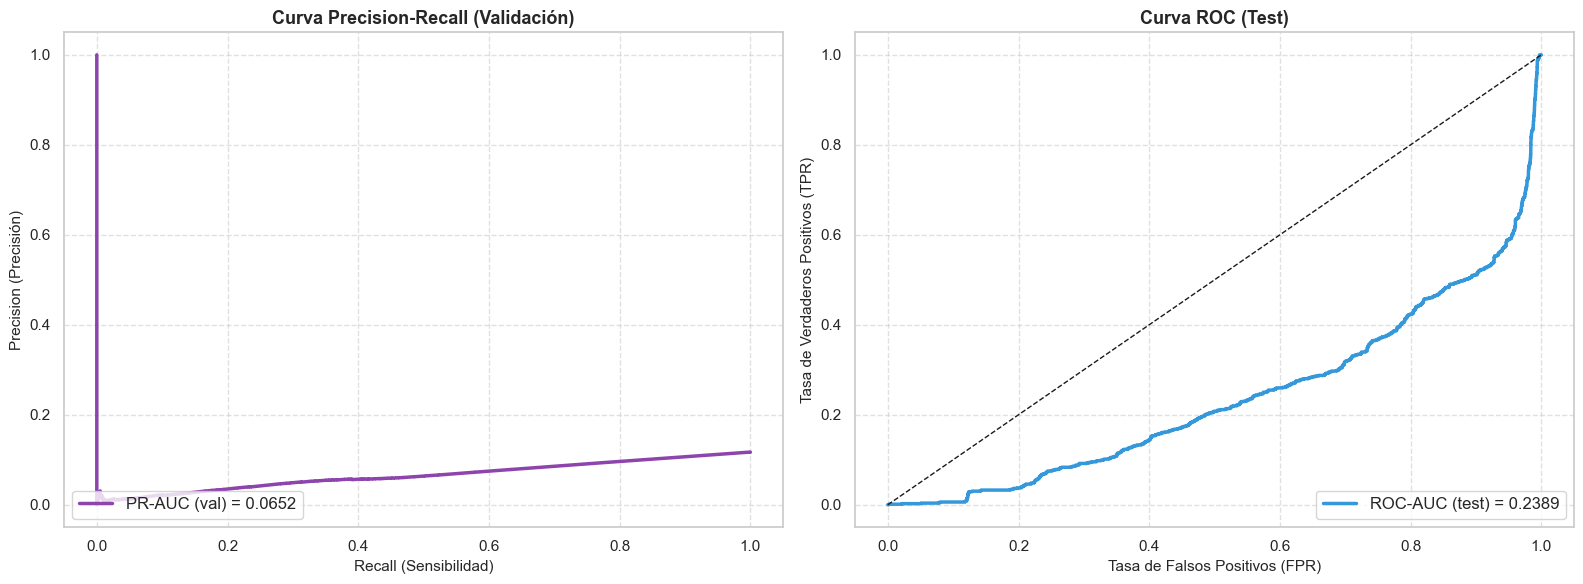

In [5]:
# 1. Curva Precision-Recall en VALIDACIÓN (selección de umbral)
precision_v, recall_v, thresholds_v = precision_recall_curve(y_val, reconstruction_errors_val)
pr_auc_val = auc(recall_v, precision_v)
avg_prec_val = None
try:
    from sklearn.metrics import average_precision_score
    avg_prec_val = average_precision_score(y_val, reconstruction_errors_val)
except Exception:
    avg_prec_val = pr_auc_val

# 2. Curva ROC en TEST (evaluación final)
fpr, tpr, _ = roc_curve(y_test, reconstruction_errors_test)
roc_auc_test = roc_auc_score(y_test, reconstruction_errors_test)
avg_prec_test = average_precision_score(y_test, reconstruction_errors_test)

# Gráfico: PR (validación) y ROC (test)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# PR Curve (Validation)
axes[0].plot(recall_v, precision_v, color='#8e44ad', lw=2.5, label=f'PR-AUC (val) = {pr_auc_val:.4f}')
axes[0].set_title("Curva Precision-Recall (Validación)", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Recall (Sensibilidad)", fontsize=11)
axes[0].set_ylabel("Precision (Precisión)", fontsize=11)
axes[0].legend(loc="lower left", fontsize=12)
axes[0].grid(True, linestyle='--', alpha=0.6)

# ROC Curve (Test)
axes[1].plot(fpr, tpr, color='#3498db', lw=2.5, label=f'ROC-AUC (test) = {roc_auc_test:.4f}')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[1].set_title("Curva ROC (Test)", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Tasa de Falsos Positivos (FPR)", fontsize=11)
axes[1].set_ylabel("Tasa de Verdaderos Positivos (TPR)", fontsize=11)
axes[1].legend(loc="lower right", fontsize=12)
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

### Optimización del Umbral de Anomalía ($\tau$) por $F_1$-Score Maximizado
Buscamos el umbral $\tau$ que optimiza el balance entre Precision y Recall ($F_1$-Score):$$F_1 = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}$$

🎯 Umbral Óptimo Seleccionado (tau) en VALIDACIÓN: 0.304355
   ├─ Precision (val) en el umbral: 0.1171
   ├─ Recall    (val) en el umbral: 1.0000
   └─ F1-Score Máximo (val):        0.2097


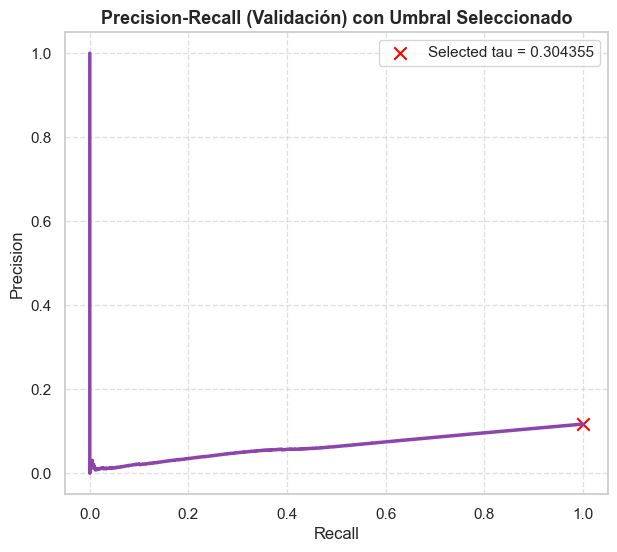

In [6]:
# Calcular F1-Score por umbral usando la curva de VALIDACIÓN
# Nota: `thresholds_v` tiene longitud N-1 y `precision_v`/`recall_v` tienen longitud N.
precision_valid = precision_v[1:]
recall_valid = recall_v[1:]
f1_scores = 2 * (precision_valid * recall_valid) / (precision_valid + recall_valid + 1e-10)

# Encontrar el índice del F1 máximo (respecto a `thresholds_v`)
best_idx = np.argmax(f1_scores)
optimal_threshold = thresholds_v[best_idx]
best_f1 = f1_scores[best_idx]

print(f"🎯 Umbral Óptimo Seleccionado (tau) en VALIDACIÓN: {optimal_threshold:.6f}")
print(f"   ├─ Precision (val) en el umbral: {precision_valid[best_idx]:.4f}")
print(f"   ├─ Recall    (val) en el umbral: {recall_valid[best_idx]:.4f}")
print(f"   └─ F1-Score Máximo (val):        {best_f1:.4f}")

# Visualizar nuevamente la curva PR de validación y marcar el punto seleccionado
point_recall = recall_v[best_idx + 1]
point_precision = precision_v[best_idx + 1]
plt.figure(figsize=(7, 6))
plt.plot(recall_v, precision_v, color='#8e44ad', lw=2.5)
plt.scatter([point_recall], [point_precision], color='red', s=80, marker='x', label=f'Selected tau = {optimal_threshold:.6f}')
plt.title('Precision-Recall (Validación) con Umbral Seleccionado', fontsize=13, fontweight='bold')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### Evaluación Final con Matriz de Confusión y Reporte

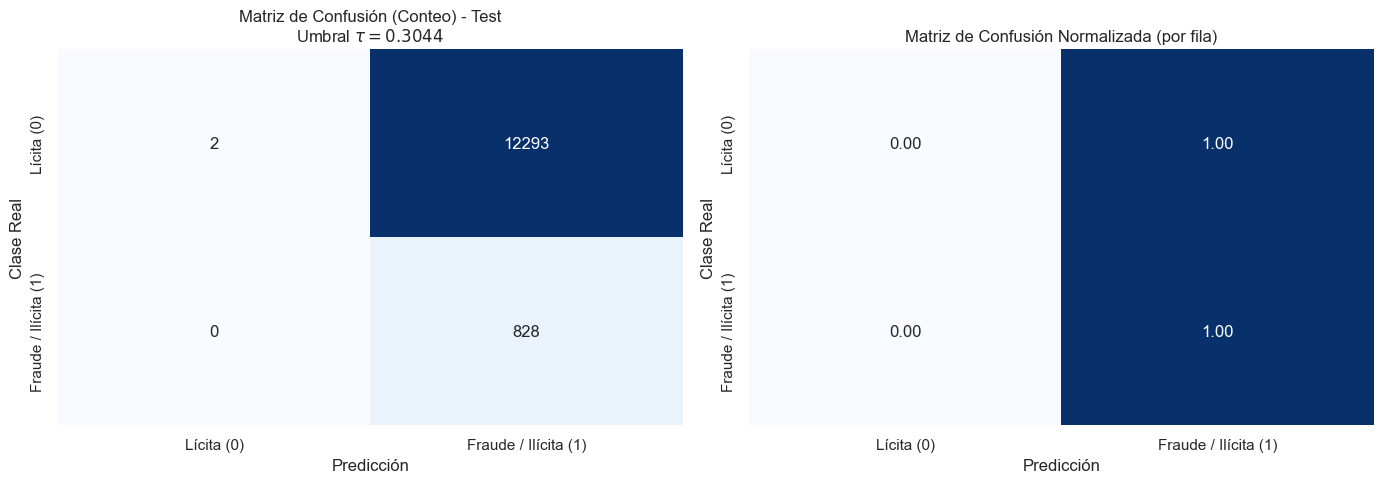


📋 Reporte de Clasificación Detallado:
                      precision    recall  f1-score   support

          Lícita (0)     1.0000    0.0002    0.0003     12295
Ilícita / Fraude (1)     0.0631    1.0000    0.1187       828

            accuracy                         0.0632     13123
           macro avg     0.5316    0.5001    0.0595     13123
        weighted avg     0.9409    0.0632    0.0078     13123


PR-AUC (average precision) en Test: 0.0380
ROC-AUC en Test: 0.2389
💾 Artefactos guardados: threshold_config.joblib, reconstruction_errors_test.npy, y_pred_test.npy en ..\data\processed


In [7]:
# Clasificar predicciones en TEST según el umbral óptimo calculado en VALIDACIÓN
y_pred = (reconstruction_errors_test >= optimal_threshold).astype(int)

# Matriz de Confusión (absoluta)
cm = confusion_matrix(y_test, y_pred)

# Matriz de Confusión Normalizada (por fila / recall por clase)
cm_norm = confusion_matrix(y_test, y_pred, normalize='true')

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["Lícita (0)", "Fraude / Ilícita (1)"],
            yticklabels=["Lícita (0)", "Fraude / Ilícita (1)"])
plt.title(f"Matriz de Confusión (Conteo) - Test\nUmbral $\\tau = {optimal_threshold:.4f}$", fontsize=12)
plt.xlabel("Predicción")
plt.ylabel("Clase Real")

plt.subplot(1, 2, 2)
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues", cbar=False,
            xticklabels=["Lícita (0)", "Fraude / Ilícita (1)"],
            yticklabels=["Lícita (0)", "Fraude / Ilícita (1)"])
plt.title("Matriz de Confusión Normalizada (por fila)", fontsize=12)
plt.xlabel("Predicción")
plt.ylabel("Clase Real")

plt.tight_layout()
plt.show()

# Métricas adicionales
from sklearn.metrics import average_precision_score
avg_prec = average_precision_score(y_test, reconstruction_errors_test)
roc_auc = roc_auc_score(y_test, reconstruction_errors_test)

print("\n📋 Reporte de Clasificación Detallado:")
print(classification_report(y_test, y_pred, target_names=["Lícita (0)", "Ilícita / Fraude (1)"], digits=4, zero_division=0))

print(f"\nPR-AUC (average precision) en Test: {avg_prec:.4f}")
print(f"ROC-AUC en Test: {roc_auc:.4f}")

# Guardar artefactos reproducibles
SEED = 42
threshold_dict = {
    "optimal_threshold": float(optimal_threshold),
    "best_f1_val": float(best_f1),
    "pr_auc_val": float(pr_auc_val),
    "avg_precision_test": float(avg_prec),
    "roc_auc_test": float(roc_auc),
    "seed": int(SEED)
}

joblib.dump(threshold_dict, PROCESSED_DATA_PATH / "threshold_config.joblib")
np.save(PROCESSED_DATA_PATH / "reconstruction_errors_test.npy", reconstruction_errors_test)
np.save(PROCESSED_DATA_PATH / "y_pred_test.npy", y_pred)

print(f"💾 Artefactos guardados: threshold_config.joblib, reconstruction_errors_test.npy, y_pred_test.npy en {PROCESSED_DATA_PATH}")

### Guardar Artefactos de Evaluación

In [8]:
# Guardar el umbral óptimo tau para inferencia en producción
threshold_dict = {
    "optimal_threshold": float(optimal_threshold),
    "best_f1_score": float(best_f1),
    "pr_auc_val": float(pr_auc_val),
    "avg_precision_test": float(avg_prec),
    "roc_auc_test": float(roc_auc),
    "seed": 42
}

joblib.dump(threshold_dict, PROCESSED_DATA_PATH / "threshold_config.joblib")

print("💾 Configuración del umbral guardada exitosamente en data/processed/threshold_config.joblib")

💾 Configuración del umbral guardada exitosamente en data/processed/threshold_config.joblib


In [9]:
# Cargar train_licit para comparar la distribución de error original
X_train_licit = np.load(PROCESSED_DATA_PATH / "X_train_licit.npy")

with torch.no_grad():
    X_tr_tensor = torch.tensor(X_train_licit, dtype=torch.float32).to(device)
    X_tr_rec = model(X_tr_tensor).cpu().numpy()

train_errors = np.mean(np.square(X_train_licit - X_tr_rec), axis=1)

test_errors_licit = reconstruction_errors_test[y_test == 0]
test_errors_fraud = reconstruction_errors_test[y_test == 1]

print("=" * 70)
print("📊 DIAGNÓSTICO 1: DISTRIBUCIÓN DE ERRORES (MSE)")
print("=" * 70)
print(f"TRAIN (Lícito)  | Min: {train_errors.min():.6f} | Mediana: {np.median(train_errors):.6f} | P95: {np.percentile(train_errors, 95):.6f} | Max: {train_errors.max():.6f}")
print(f"TEST  (Lícito)  | Min: {test_errors_licit.min():.6f} | Mediana: {np.median(test_errors_licit):.6f} | P95: {np.percentile(test_errors_licit, 95):.6f} | Max: {test_errors_licit.max():.6f}")
print(f"TEST  (Ilícito) | Min: {test_errors_fraud.min():.6f} | Mediana: {np.median(test_errors_fraud):.6f} | P95: {np.percentile(test_errors_fraud, 95):.6f} | Max: {test_errors_fraud.max():.6f}")
print("=" * 70)

📊 DIAGNÓSTICO 1: DISTRIBUCIÓN DE ERRORES (MSE)
TRAIN (Lícito)  | Min: 16225.463477 | Mediana: 33930.392698 | P95: 6053593666.072150 | Max: 310730833150691.812500
TEST  (Lícito)  | Min: 0.300931 | Mediana: 0.979999 | P95: 6.322410 | Max: 404.393414
TEST  (Ilícito) | Min: 0.347782 | Mediana: 0.558722 | P95: 1.951103 | Max: 52.271766


In [10]:
print("=" * 70)
print("⚙️ DIAGNÓSTICO 2: INSPECCIÓN DE VECTORES Y UMBRAL")
print("=" * 70)
print(f"Tamaño Precision (val):  {len(precision_v)}")
print(f"Tamaño Recall    (val):  {len(recall_v)}")
print(f"Tamaño Thresholds (val): {len(thresholds_v)}")
print(f"Índice Seleccionado (best_idx): {best_idx}")
print(f"Umbral Calculado (tau): {optimal_threshold:.6f}")
print(f"Error Mínimo en Test:   {reconstruction_errors_test.min():.6f}")
print(f"Error Máximo en Test:   {reconstruction_errors_test.max():.6f}")
print(f"¿Tau < Mínimo error de Test?: {optimal_threshold < reconstruction_errors_test.min()}")
print("=" * 70)

⚙️ DIAGNÓSTICO 2: INSPECCIÓN DE VECTORES Y UMBRAL
Tamaño Precision (val):  6528
Tamaño Recall    (val):  6528
Tamaño Thresholds (val): 6527
Índice Seleccionado (best_idx): 20
Umbral Calculado (tau): 0.304355
Error Mínimo en Test:   0.300931
Error Máximo en Test:   404.393414
¿Tau < Mínimo error de Test?: False
